In [1]:
import sys
sys.path.append('/Users/anyaphillips/Desktop/harvard/research/via_binaries/scripts')

import PETAR_ANALYSIS_FUNCTIONS as paf
import petar
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('vedant')
%matplotlib inline
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from astropy.table import Table
from scipy.stats import binned_statistic_2d

from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
from matplotlib import gridspec
from matplotlib.lines import Line2D


from tqdm import tqdm

import pandas as pd

import astropy.constants as const
import astropy.units as u
from scipy.stats import binned_statistic
from matplotlib.gridspec import GridSpecFromSubplotSpec

import matplotlib.pyplot as plt
%config InlineBackend.figure_format='retina'

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.colors import LinearSegmentedColormap

lm_colors, hm_colors, simcolors = paf.define_simcolors()
time_cmap = paf.define_time_cmap()

Duplicate key in file PosixPath('/Users/anyaphillips/.matplotlib/stylelib/vedant.mplstyle'), line 46 ('lines.linewidth : 3')

Bad key hist.type in file /Users/anyaphillips/.matplotlib/stylelib/vedant.mplstyle, line 45 ('hist.type : step')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.10.0/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution
/opt/anaconda3/envs/petar_env3/lib/python3.10/site-packages/matplotlib_inline/config.py:68: DeprecationWarning: InlineBackend._figure_format_changed is deprecated in traitlets 4.1: use @observe and @unobserve instead.
  def _figure_format_changed(self, name, old, new):


In [2]:
### load binaries: 

binaries = pd.read_csv('cosmic_example_IBC.csv')
N = len(binaries)
print(N)

15000


In [3]:
def calc_K(Mtot, M2, a, e, P, i):
    a1 = (M2/Mtot) * a

    num = 2*np.pi*a1 *np.sin(i)# nominally this would include sin(i)
    denom = P * np.sqrt(1-(e**2))
    K = num/denom # velocity semiamplitude - multiply by 2 for full amplitude.
    return K 

def calc_a(P, Mtot):
    """
    asdf
    """
    a = (P**2 * const.G * Mtot / (4*np.pi**2))**(1/3)
    return a

In [4]:
# do nominal mock observations
### stack orbital params. want v0 (km/s), K (km/s), w, phi0, e, P (day)
rng = np.random.default_rng(seed=42)

m1 = binaries['mass_1'].values * u.Msun
m2 = binaries['mass_2'].values * u.Msun
mtot = m1+m2
P = binaries['porb'].values * u.day # days
a = calc_a(P, mtot)

e = binaries['ecc'].values
i = paf.draw_inclinations(N, rng=rng)
K = calc_K(mtot, m2, a, e, P, i)
v0 = np.zeros(N)*(u.km/u.s)

w = rng.uniform(low=0, high=2*np.pi, size=N)
phi0 = rng.uniform(low=0, high=1, size=N)

# params = np.array([
#     v0.to(u.km/u.s).value,
#     K.to(u.km/u.s).value, 
#     w,
#     phi0,
#     e,
#     P.to(u.day).value
# ]).T

# results from `detection_fractions_sparse`

In [13]:
# institutional knowledge of what I ran in the slurm array. 
dt1_min, dt1_max, dt1_step = 2,150,2
dt1_vals  = np.arange(dt1_min, dt1_max+dt1_step, dt1_step) 

dt2_min, dt2_max, dt2_step = 30, 10*365, 10
dt2_vals = np.arange(dt2_min, dt2_max+dt2_step, dt2_step)

dfa = []

for k, dt1 in enumerate(dt1_vals):
    dfa_this_dt1 = np.loadtxt("detection_fractions_sparse/ms_%i.txt"%k)
    dfa.append(dfa_this_dt1)
dfa = np.array(dfa)
len(dt2_vals)

363

/var/folders/q2/m18s57611677cjnvtmvry2v80000gn/T/ipykernel_68975/3596073738.py:35: UserWarning: The following kwargs were not used by contour: 'linestyle'
  ob = ax.contour(X,Y,Z, levels=np.arange(0.36, 0.60, 0.01),


<a list of 22 text.Text objects>

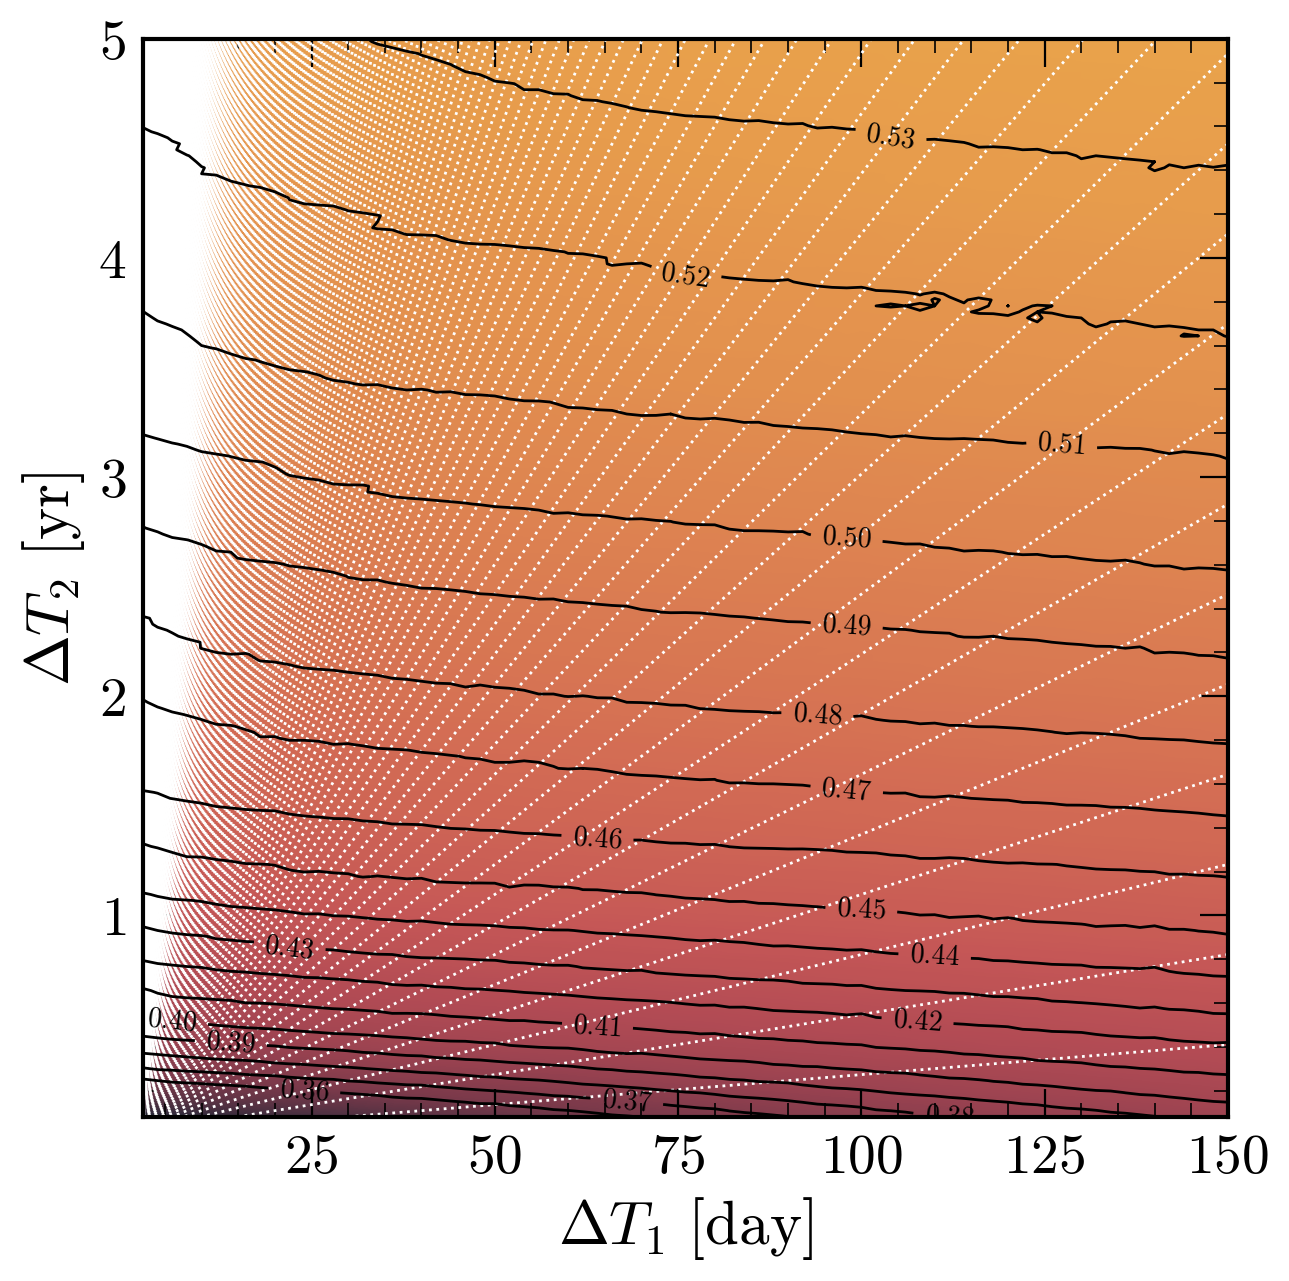

In [14]:
colors=["#212738","#4D3041","#79394A","#994250","#B24B54","#C55756","#D26A54","#DC8051","#E5974D","#EDAE49", "gold"]
# colors.reverse()
# colors = paf.define_simcolors()
df_cmap = LinearSegmentedColormap.from_list('df_cmap', colors)#[1]+colors[0])

X, Y = np.meshgrid(dt1_vals, dt2_vals)
Z = dfa.T

Y = Y/365
fig, ax = plt.subplots()
# ax.imshow(dfa, cmap=time_cmap)
ob = ax.contourf(X,Y, Z, cmap=df_cmap, levels=1000)
divider = make_axes_locatable(ax)
# cax = divider.append_axes('right', size='5%', pad=0.05)
# cax.set_yticklabels(np.arange(0.44, 0.53, 0.01))
# fig.colorbar(ob, cax=cax, label=r"detection fraction")


### add lines where dt2 is an integer multiple of dt1
x = np.linspace(np.min(dt1_vals), np.max(dt1_vals), 100)
n_vals = np.arange(1, 1000, 1)
for n in n_vals:
    y = n*x
    y = y/365
    ax.plot(x,y, c='white', lw=1, ls=':')



ax.set_ylim(np.min(Y), 5)#np.max(Y))
ax.set_xlabel(r"$\Delta T_1~\rm [day]$")
ax.set_ylabel(r'$\Delta T_2~\rm [yr]$')
# ax.set_xscale('log')
# ax.set_yscale('log')

ob = ax.contour(X,Y,Z, levels=np.arange(0.36, 0.60, 0.01),
           linestyle="solid", colors="k", linewidths=1)
ax.clabel(ob, ob.levels, fontsize=10)

# results from `detection_fractions_dense`

In [10]:
### eventually, do Delta t_1 in 1-day increments, 
# delta t2 from like 1--360 days also in 1-day increments. 
# this will be the check on whether period aliasing is a problem or not


# institutional knowledge of what I ran in the slurm array. 
dt1_min, dt1_max, dt1_step = 1,150,1
dt1_vals  = np.arange(dt1_min, dt1_max+dt1_step, dt1_step) 

dt2_min, dt2_max, dt2_step = 1, 2*365, 1
dt2_vals = np.arange(dt2_min, dt2_max+dt2_step, dt2_step)

dfa = []

# for k, dt1 in enumerate(dt1_vals):
#     dfa_this_dt1 = np.loadtxt("get_detection_fractions_dense/ms_%i.txt"%k)
#     dfa.append(dfa_this_dt1)
# dfa = np.array(dfa)

In [11]:
len(dt2_vals) # will take >~twice as long to run as the sparse version

730

In [ ]:
# plots here. 

# results from adding visits/compromising SNR. 

In [ ]:
### also:
# change number of visits and include a SNR hit -- see via science book -- total exposure time should be the same.
#  